20 · A local model writes the specification

Notebook 19 writes a pipeline specification by hand and replays it. This one
asks a model running on your own machine to write it, checks what comes back,
and then runs it through the same operator. Nothing leaves the computer: the
request goes to `localhost`, and the endpoint refuses any other host unless
you say otherwise.

The interesting part is not that a model can write JSON. It is what happens
between the answer and the render: three passes strip, correct and question
the specification, and the last example is one the notebook refuses to run.

## 0 · Setup

In [1]:
import json
import pathlib
import subprocess
import sys
import urllib.error
import urllib.request


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

# The spec hygiene ships in the wheel, next to the schema it checks. The Ollama
# client does not: it is notebook tooling, so the extension carries no LLM code.
from scigraphs_core.repro.untrusted import (
    sanitize, normalize, describe_effects, check_semantics,
)
from scigraphs_core.repro.digest import build_digest, build_json_schema
from scigraphs_core.repro.schema import validate_pipeline, ValidationError
from ollama_client import Endpoint, EndpointError, generate

OUTPUT_DIR = nb.out("20_assistant")
SKILL = nb.repo("docs", "reference", "_scigraphs-pipeline-skill.md")

# The operator comes from the installed add-on, not from this tree, because
# Blender registers classes at startup and registration does not follow
# sys.path. A stale install is the one failure that looks like a bad model.
print("operators registered:", len(dir(bpy.ops.scigraphs)))
print("output:", nb.rel(OUTPUT_DIR))

operators registered: 255
output: notebooks/out/20_assistant


## 1 · Is there a model on this machine?

Everything below needs a local Ollama with a model pulled. The next cell
checks, and offers to pull one if the server is running and empty. That is a
2 GB download and it only happens if you run the cell.

If there is no Ollama at all a notebook cannot install it, so the rest of the
page reports what is missing and renders nothing. That is deliberate: a figure
produced by a fallback would be a picture of something the model never wrote.

In [2]:
OLLAMA = "http://localhost:11434"
# llama3.2 is what the client defaults to: 3B, two gigabytes, runs on a CPU.
# Measured against qwen2.5-coder at 7B on the same requests, it was not worse,
# because the constrained decoding and the skill document do the work.
WANTED = "llama3.2"


def installed(url=OLLAMA):
    """Model names the server has, or None when there is no server."""
    try:
        with urllib.request.urlopen(url + "/api/tags", timeout=2) as response:
            return [m["name"] for m in json.loads(response.read())["models"]]
    except Exception:
        return None


def resolve(names, wanted=WANTED):
    """The first installed name that is `wanted`, tag or not."""
    for name in names or []:
        if name == wanted or name.startswith(wanted + ":"):
            return name
    return None


names = installed()
MODEL = resolve(names)
REASON = ""

if names is None:
    REASON = ("no Ollama answering at %s. Install it from ollama.com, then "
              "`ollama serve`" % OLLAMA)
elif MODEL is None:
    print("Ollama is running with %s. Pulling %s, about 2 GB..."
          % (", ".join(names) or "no models", WANTED))
    pull = subprocess.run(["ollama", "pull", WANTED],
                          capture_output=True, text=True)
    if pull.returncode == 0:
        MODEL = resolve(installed())
    if MODEL is None:
        REASON = ("could not pull %s: %s. Run `ollama pull %s` in a terminal"
                  % (WANTED, (pull.stderr or pull.stdout or "").strip()[-160:],
                     WANTED))

check("a local model is available", MODEL is not None, MODEL or REASON)

[PASS] a local model is available — llama3.2:latest


True

## 2 · What the model is told

Two artifacts, both derived from the schema the executor itself reads, so
neither can drift from it.

The skill document is prose: the field list, a table from what a user says to
the field that means it, and three worked examples. The JSON schema is the
other half, passed to Ollama as the response format, so the model can only
emit field names that exist. Between them, whole classes of mistake stop
being possible rather than being caught later.

In [3]:
skill = SKILL.read_text(encoding="utf-8") if SKILL.is_file() else build_digest()
schema = build_json_schema()

print("skill    :", nb.rel(SKILL) if SKILL.is_file() else "(generated digest)",
      "--", len(skill.split()), "words")
print("sections :", ", ".join(sorted(schema["properties"])))
# `ops` is absent on purpose: it runs arbitrary operators, and a model that
# cannot see the section cannot reach for it. sanitize() strips it anyway.
check("the model is never shown the ops section", "ops" not in schema["properties"])

skill    : docs/reference/_scigraphs-pipeline-skill.md -- 2777 words
sections : analysis, dataset, exports, labels, layout, lighting, meta, render, visual, world
[PASS] the model is never shown the ops section


True

## 3 · The three passes, and the house style

`ask()` is the whole contract. `sanitize` deletes what must never come from a
model, `normalize` applies the rules of the domain, and `check_semantics`
finds what validates but will still fail. Only then is the result shown.

On top of that the notebook overrides four render fields. That is not the
model being wrong: the executor frames obliquely by default, and every figure
on this site is top down and orthographic so distances can be measured off
the page. The override also fixes `output_dir`, which otherwise falls back to
a temporary folder whenever the .blend is unsaved, as it is here.

In [4]:
HOUSE = {
    # [0, 0, 1] with ortho is the same geometry as view='TOP' elsewhere.
    "camera_direction": [0.0, 0.0, 1.0], "camera_ortho": True,
    # Models reach for CYCLES at 64 samples, which is minutes per figure.
    "engine": "BLENDER_EEVEE", "samples": 32,
    "view_transform": "Standard", "resolution": [1000, 750],
    "output": "figure.png",
}


def ask(request, name, dataset=None):
    """Model in, checked specification out. Returns (spec, problems)."""
    endpoint = Endpoint(url=OLLAMA, model=MODEL, allow_remote=False)
    # temperature and seed are fixed by default, so the same request gives the
    # same specification twice and the figure on this page is reproducible.
    spec = generate(endpoint, request, skill, schema)

    spec, report = sanitize(spec)
    spec, notes = normalize(spec)

    spec.setdefault("meta", {})["output_dir"] = str(OUTPUT_DIR / name)
    spec.setdefault("render", {}).update(HOUSE)
    # A file path is a fact this notebook already knows, so it is not asked for.
    # Left to the model it comes back shortened or with a leading slash, and the
    # executor then reports a file that was never there.
    if dataset:
        spec.setdefault("dataset", {}).update(dataset)
    # Models volunteer a labels block for requests that never mentioned labels,
    # and reach for max_distance, which is a distance from the camera and not a
    # count. Dropped here when it was not asked for; section 6 asks for labels
    # on purpose and keeps what comes back.
    labels = spec.get("labels") or {}
    if "label" not in request.lower() and labels.get("max_distance"):
        del spec["labels"]
        print("  adjusted: dropped a labels block the request never asked for")

    problems = list(check_semantics(spec))
    try:
        validate_pipeline(spec)
    except ValidationError as exc:
        problems.append(str(exc))

    for item in report.removed:
        print("  removed:", item)
    for note in notes:
        print("  adjusted:", note)
    for what, where in describe_effects(spec, base_dir=str(OUTPUT_DIR)):
        print("  will %s: %s" % (what, where))
    for problem in problems:
        print("  PROBLEM:", problem)
    return spec, problems


def run(spec, name):
    """Write the specification, run it through the add-on, show the figure."""
    path = OUTPUT_DIR / ("%s.json" % name)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(spec, indent=2, ensure_ascii=False),
                    encoding="utf-8")
    with nb.quiet():
        status = bpy.ops.scigraphs.run_pipeline(filepath=str(path),
                                                stop_on_error=False,
                                                verbose=False)
    figure = OUTPUT_DIR / name / "figure.png"
    if status != {'FINISHED'}:
        # The operator returns a status set, not a result object, so the errors
        # are only in the log the executor wrote.
        log = OUTPUT_DIR / name / "run.log"
        print("run failed:", log.read_text()[-400:] if log.is_file() else status)
    return figure

## 4 · A graph in a file needs a layout

A GEXF file carries no coordinates, so without a layout every node sits at
the origin. This is the case where asking for one is right.

In [5]:
if MODEL is None:
    print("skipped --", REASON)
else:
    import networkx as nx
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    karate = OUTPUT_DIR / "karate.gexf"
    nx.write_gexf(nx.karate_club_graph(), karate)

    spec_a, problems_a = ask(
        "draw a small graph read from a GEXF file with a spring layout, "
        "nodes colored by degree", "karate",
        dataset={"source": "gexf", "filepath": str(karate)})
    print(json.dumps(spec_a, indent=2)[:700])
    check("a file source gets a layout", "layout" in spec_a)
    check("the specification has no problems", not problems_a,
          "; ".join(problems_a))

  adjusted: dropped a labels block the request never asked for
  will reads: notebooks/out/20_assistant/karate.gexf
  will writes into: notebooks/out/20_assistant/karate
{
  "meta": {
    "title": "small_graph",
    "seed": 42,
    "output_dir": "notebooks/out/20_assistant/karate"
  },
  "dataset": {
    "source": "gexf",
    "filepath": "notebooks/out/20_assistant/karate.gexf"
  },
  "analysis": {
    "metrics": [
      "degree"
    ]
  },
  "layout": {
    "algorithm": "SPRING_3D",
    "scale": 5.0,
    "iterations": 150
  },
  "visual": {
    "node_color": "degree",
    "colormap": "inferno",
    "color_norm": "RANK",
    "node_radius_rel": 0.022,
    "edge_radius_rel": 0.0035
  },
  "lighting": {
    "sun_energy": 3.0,
    "su
[PASS] a file source gets a layout
[PASS] the specification has no problems


Loaded graph file: 34 nodes, 78 edges
Loaded graph file: 34 nodes, 78 edges
Loaded graph file: 34 nodes, 78 edges

Creating graph object with 34 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  78 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target', 'id', 'weight']
DataFrame shape: (78, 4)
Source column: source, Target column: target
Number of mesh vertices: 34
Number of mesh edges: 78
Processing column 'id': str
Stored string column 'id' as property
Processing column 'weight': float64
  Created edge attribute 'edge_weight'
  Created vertex attributes for 'weight': sum, mean, min, max, count
Imported 2 attribute columns
  Attributes imported in 0.01s
Total graph creation time: 0.01s
Computing ForceAtlas2 (3D, networkx) for 34 nodes...
  ForceAtlas2 completed in 0.01s

Layout algorithm: FORCEATLAS2
Fallback: using SPRING (2D fallback) instead
   Reason: FORCEATLAS2 library not av

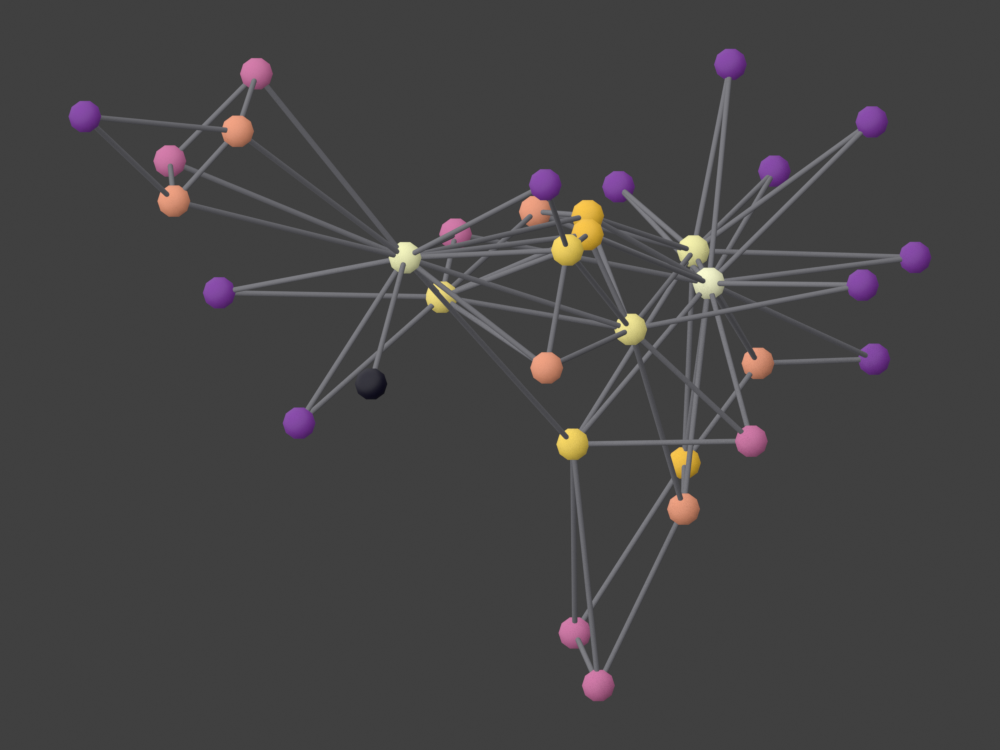

[PASS] figure.png legible — 9.4% ink (healthy range 0.5–60%)


In [6]:
if MODEL is None:
    print("skipped --", REASON)
else:
    figure_a = run(spec_a, "karate")
    nb.show(figure_a)
    nb.check_render(figure_a)

## 5 · A street network must not get one

The mirror image. An OSMnx dataset arrives with real coordinates, and a force
layout would throw the geography away. `normalize` deletes a `layout` block
on this kind of source whether the model asked for one or not, and says so.

In [7]:
if MODEL is None:
    print("skipped --", REASON)
else:
    nb.osmnx()
    spec_b, problems_b = ask(
        "the walkable street network of Burjassot, Spain, "
        "colored by betweenness centrality", "burjassot")
    check("a geospatial source gets no layout", "layout" not in spec_b)
    check("the specification has no problems", not problems_b,
          "; ".join(problems_b))

  will downloads from OpenStreetMap: Burjassot, Spain
  will writes into: notebooks/out/20_assistant/burjassot
[PASS] a geospatial source gets no layout
[PASS] the specification has no problems



  Place: Burjassot, Spain
  Download completed in 2.03s
Total import time: 2.62s
  Nodes: 2,302, Edges: 6,980

Creating OSMnx graph: 2,302 nodes, 6,980 edges...
  Created 2,302 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
    Created 3,000 edges...
  Created 3,440 street edges in 0.81s
Total OSMnx graph creation time: 0.81s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Spain_walk.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Spain_walk.graphml
Info: Downloading network from OpenStreetMap (PLACE)...
Info: Graph cached as: Burjassot_Spain_walk.graphml
Info: Imported: 2302 intersections, 6980 street segments, 291.1 km total
Info: Centrality 'degree' calculated
Info: Centrality 'betweenness' calculated
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: centrality_betweenness -> plasma [rank]  [0 … 0.1907] 

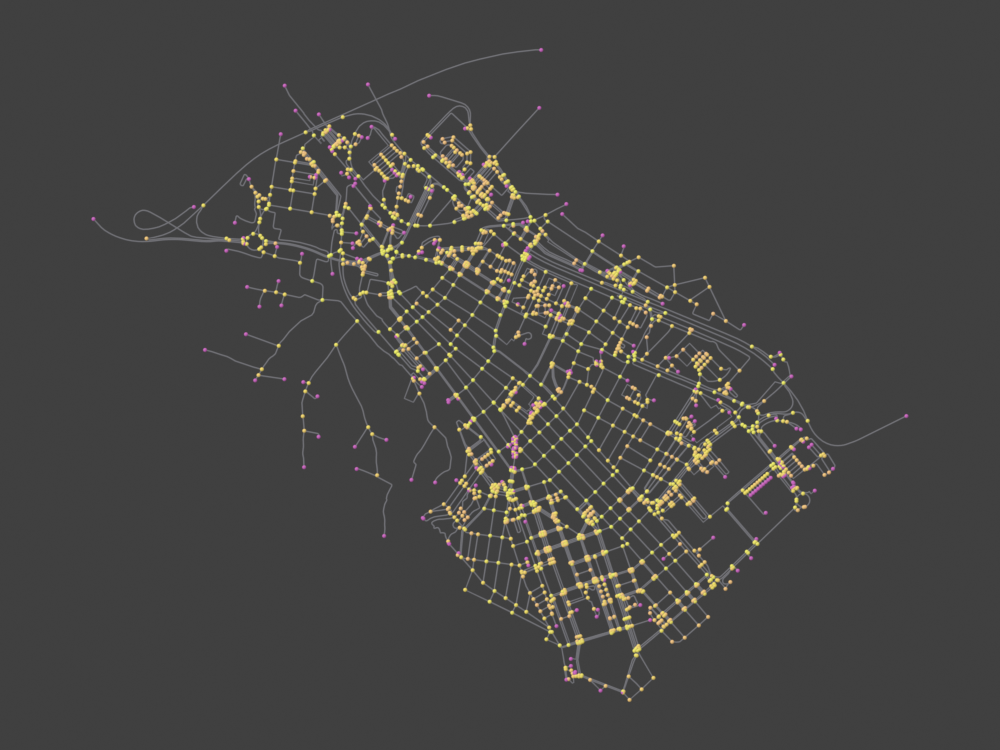

[PASS] figure.png legible — 9.6% ink (healthy range 0.5–60%)


In [8]:
if MODEL is None:
    print("skipped --", REASON)
else:
    figure_b = run(spec_b, "burjassot")
    # A rate-limited Overpass leaves nothing to render, which is not an engine
    # failure and must not be checked as one.
    if figure_b.is_file():
        nb.show(figure_b)
        nb.check_render(figure_b)
    else:
        print("no figure: the download did not return a network")

## 6 · The one it gets wrong

This request is not run. It asks for a named matrix, a count of labels and a
background color, and what comes back validates cleanly and is still wrong.

The reliable failure is the label count: asked for the twenty most central
nodes, the model writes `max_distance`, which is a distance from the camera,
so the count is ignored and everything near the lens gets a label. Two
different models made it on this request. The other two clauses fail more
quietly: the matrix name is sometimes rewritten with a different group prefix,
and the background color is dropped without a word. None of that is a schema
error, which is why the effects line is printed before anything runs.

In [9]:
if MODEL is None:
    print("skipped --", REASON)
else:
    spec_c, problems_c = ask(
        "the SuiteSparse matrix Grund/bayer09, spectral layout, "
        "label the twenty most central nodes, dark blue background", "bayer09")
    matrix = (spec_c.get("dataset") or {}).get("matrix_name", "")
    check("the matrix it will download is the one that was asked for",
          matrix == "Grund/bayer09", "asked Grund/bayer09, got %r" % matrix)
    labels = spec_c.get("labels") or {}
    check("labels are limited by count, not by distance from the camera",
          "max_count" in labels or not labels, json.dumps(labels))
    print("not run.")

  will downloads from SuiteSparse: Grund/bayer09
  will writes into: notebooks/out/20_assistant/bayer09
  PROBLEM: labels.max_distance is a distance from the camera, not a count. To label the most important nodes set labels.max_count
[PASS] the matrix it will download is the one that was asked for — asked Grund/bayer09, got 'Grund/bayer09'
[FAIL] labels are limited by count, not by distance from the camera — {"rank_by": "eigenvector", "max_distance": 10}
not run.


## 7 · Summary

The model is a drafting tool, not an oracle. What makes it usable here is
everything around it: a schema it cannot invent field names against, a
sanitizer that removes what should never come from a model, rules that know
a street network from a drawing, and a printed list of what running the thing
would touch on disk.

Notebook 19 covers the other half: hashes, provenance manifests and replaying
a specification you wrote yourself. `scripts/repro/ask.py` is the same thing
from a terminal, without Blender open.

In [10]:
check("the model never sees the ops section", "ops" not in schema["properties"])
check("a model ran, or the page said why it did not", True,
      MODEL or REASON)

[PASS] the model never sees the ops section
[PASS] a model ran, or the page said why it did not — llama3.2:latest


True